# Experiment Analysis — Criticality × Vulnerability

This notebook:
1. Analyses Round 1 (criticality) and Round 2 (vulnerability) experiment outputs
2. Combines them into a priority matrix with quadrant classification
3. Generates all visualisations for the report

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 150

R1_DIR = '../experiment/round1_criticality'
R2_DIR = '../experiment/round2_vulnerability'
IMG_DIR = '../img'

## 1. Round 1 — Criticality Results

In [49]:
# Load criticality scores
crit = pd.read_csv(f'{R1_DIR}/criticality_scores.csv')
print(f'Bridges: {len(crit)}')
print(f'Disconnecting: {(crit["broken_pct"] > 0).sum()}')
print(f'\nCriticality score distribution:')
print(crit['criticality_score'].describe().round(3))
print(f'\nBroken_pct tiers:')
print(crit['broken_pct'].value_counts().sort_index(ascending=False))

Bridges: 737
Disconnecting: 409

Criticality score distribution:
count    737.000
mean       0.312
std        0.217
min        0.000
25%        0.181
50%        0.297
75%        0.475
max        1.000
Name: criticality_score, dtype: float64

Broken_pct tiers:
broken_pct
50.33     20
42.48     20
29.41     40
11.11    329
0.00     328
Name: count, dtype: int64


In [50]:
# Top 20 most critical bridges
top20_crit = crit.head(20)
display_cols = ['criticality_rank', 'bridge_id', 'road', 'name', 'condition',
                'avg_trucks_crossed', 'broken_pct', 'criticality_score']
top20_crit[display_cols].round(3)

,criticality_rank,bridge_id,road,name,condition,avg_trucks_crossed,broken_pct,criticality_score
0,1,2000378,N2,Bridge start,B,30351.6,50.33,1.0
1,2,2000366,N2,Bridge start,B,30351.0,50.33,1.0
2,3,2000374,N2,Bridge start,B,30350.7,50.33,1.0
3,4,2000370,N2,Bridge start,B,30350.6,50.33,1.0
4,5,2000360,N2,Bridge start,B,30349.1,50.33,1.0
5,6,2000346,N2,KHATABARI CULVERT,A,30348.8,50.33,1.0
6,7,2000356,N2,Bridge start,B,30347.9,50.33,1.0
7,8,2000350,N2,Bridge start/ Start of Habiganj road Division ...,B,30346.7,50.33,1.0
8,9,2000330,N2,Bridge start,B,30345.9,50.33,1.0
9,10,2000324,N2,Bridge start,B,30344.7,50.33,1.0


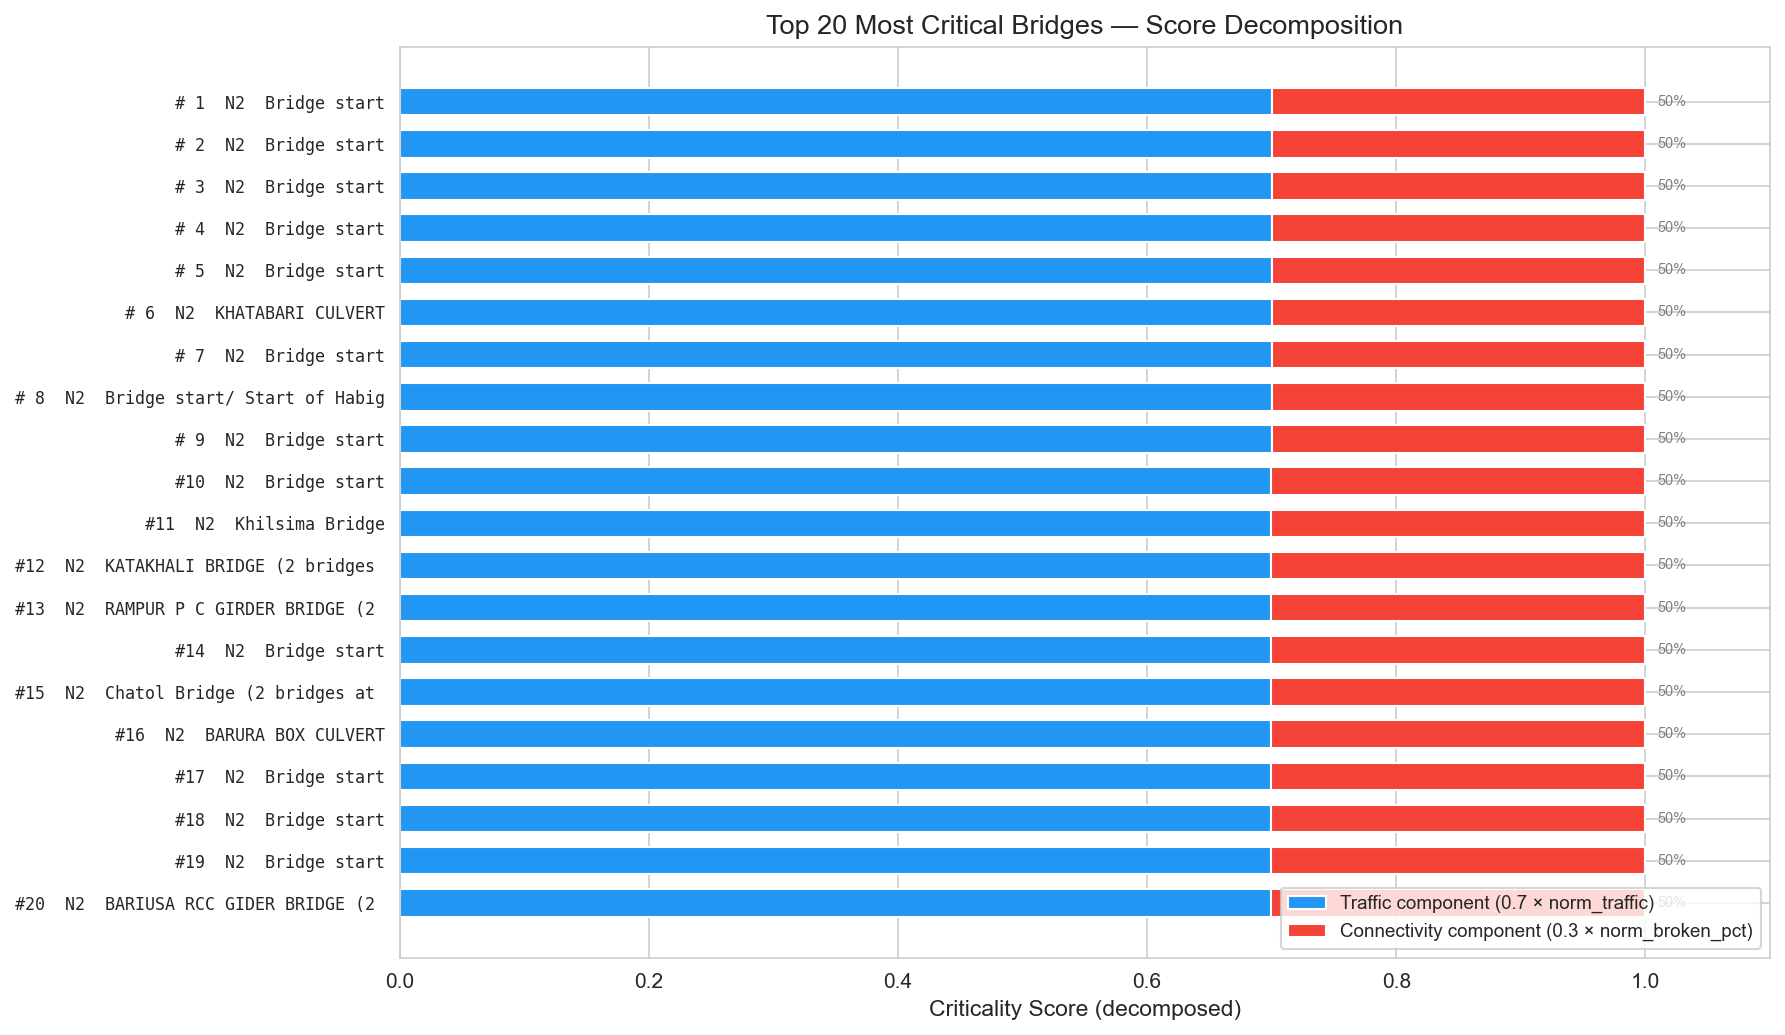

In [51]:
# Figure 1: Top 20 critical bridges — decomposed score
fig, ax = plt.subplots(figsize=(12, 7))

top20 = crit.head(20).copy()
top20['label'] = top20.apply(
    lambda r: f"#{int(r['criticality_rank']):2d}  {r['road']}  {str(r['name'])[:28]}" if pd.notna(r['name']) else f"#{int(r['criticality_rank']):2d}  {r['road']}", axis=1)
top20 = top20.iloc[::-1]  # reverse so #1 is at top

y = np.arange(len(top20))
c_contrib = 0.7 * top20['norm_traffic'].values
v_contrib = 0.3 * top20['norm_connectivity'].values

ax.barh(y, c_contrib, color='#2196F3', label='Traffic component (0.7 × norm_traffic)', height=0.65)
ax.barh(y, v_contrib, left=c_contrib, color='#F44336', label='Connectivity component (0.3 × norm_broken_pct)', height=0.65)

ax.set_yticks(y)
ax.set_yticklabels(top20['label'], fontsize=8, fontfamily='monospace')
ax.set_xlabel('Criticality Score (decomposed)', fontsize=11)
ax.set_title('Top 20 Most Critical Bridges — Score Decomposition', fontsize=13)
ax.legend(loc='lower right', fontsize=9)
ax.set_xlim(0, 1.1)

# Add broken_pct text at the end of each bar
for i, (_, row) in enumerate(top20.iterrows()):
    ax.text(row['criticality_score'] + 0.01, i, f"{row['broken_pct']:.0f}%",
            va='center', fontsize=7, color='gray')

plt.tight_layout()
plt.savefig(f'{IMG_DIR}/top20_critical_bridges.png', bbox_inches='tight')
plt.show()


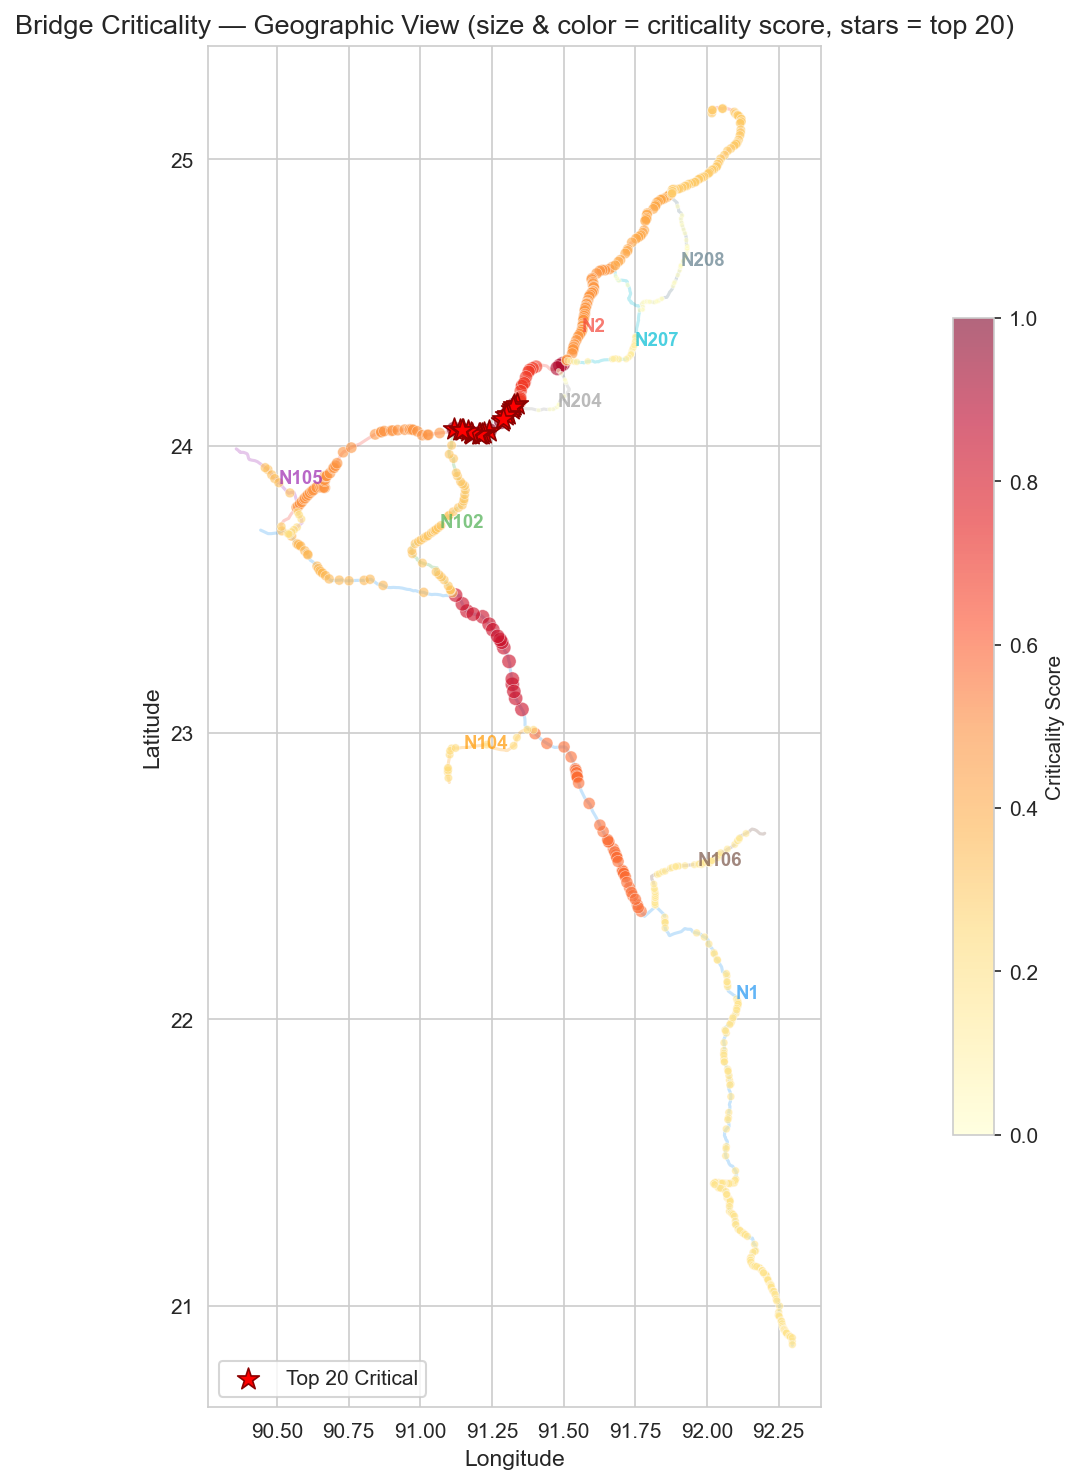

In [52]:
# Figure 2: Criticality geographic map
fig, ax = plt.subplots(figsize=(18, 10))

road_colors = {
    'N1': '#2196F3', 'N2': '#F44336', 'N102': '#4CAF50', 'N104': '#FF9800',
    'N105': '#9C27B0', 'N106': '#795548', 'N204': '#9E9E9E', 'N207': '#00BCD4', 'N208': '#607D8B'
}

# Road lines
net = pd.read_csv('../data/integrated_data.csv')
for road in net['road'].unique():
    rd = net[net['road'] == road]
    ax.plot(rd['lon'], rd['lat'], '-', color=road_colors.get(road, 'gray'),
            alpha=0.25, linewidth=1.5)

# All bridges colored by criticality
sc = ax.scatter(crit['lon'], crit['lat'],
                c=crit['criticality_score'], cmap='YlOrRd',
                s=crit['criticality_score'] * 50 + 5,
                alpha=0.6, edgecolors='white', linewidth=0.3, zorder=3)
plt.colorbar(sc, ax=ax, label='Criticality Score', shrink=0.6)

# Highlight top 20 — smaller stars, no text labels
top20 = crit.head(20)
ax.scatter(top20['lon'], top20['lat'], s=120, c='red', marker='*',
           edgecolors='darkred', linewidth=0.8, label='Top 20 Critical', zorder=5)

# Road name labels
for road in net['road'].unique():
    rd = net[net['road'] == road]
    mid = rd.iloc[len(rd)//2]
    ax.text(mid['lon'], mid['lat'], road, fontsize=9, fontweight='bold',
            color=road_colors.get(road, 'gray'), alpha=0.7)

ax.set_xlabel('Longitude', fontsize=11)
ax.set_ylabel('Latitude', fontsize=11)
ax.set_title('Bridge Criticality — Geographic View (size & color = criticality score, stars = top 20)', fontsize=13)
ax.legend(loc='lower left', fontsize=10)
ax.set_aspect('equal')
plt.tight_layout()
plt.savefig(f'{IMG_DIR}/criticality_map.png', bbox_inches='tight')
plt.show()


## 2. Round 2 — Vulnerability Results

In [53]:
# Aggregate vulnerability across all scenarios
scenarios = ['dry_season', 'pre_monsoon', 'post_monsoon', 'monsoon_peak']
vuln_parts = []

for scenario in scenarios:
    df = pd.read_csv(f'{R2_DIR}/{scenario}_bridges.csv')
    agg = df.groupby('bridge_id').agg(
        failure_rate=('broken_down', 'mean'),
        expected_delay=('total_delay_min', 'mean'),
        mean_vehicles_delayed=('vehicles_delayed', 'mean'),
    ).reset_index()
    
    # Mean delay only when failed
    failed = df[df['broken_down']].groupby('bridge_id')['total_delay_min'].mean()
    agg['mean_delay_when_failed'] = agg['bridge_id'].map(failed).fillna(0)
    agg['scenario'] = scenario
    vuln_parts.append(agg)

vuln_all = pd.concat(vuln_parts, ignore_index=True)
print(f'Vulnerability data: {len(vuln_all)} rows ({len(vuln_all)//4} bridges x {len(scenarios)} scenarios)')

# Show monsoon peak summary
monsoon = vuln_all[vuln_all['scenario'] == 'monsoon_peak'].sort_values('expected_delay', ascending=False)
print(f'\nMonsoon peak — Top 10 most vulnerable:')
monsoon.head(10)

Vulnerability data: 2948 rows (737 bridges x 4 scenarios)

Monsoon peak — Top 10 most vulnerable:


,bridge_id,failure_rate,expected_delay,mean_vehicles_delayed,mean_delay_when_failed,scenario
2521,2000175,0.5,421127.2,6279.9,8.422544e+05,monsoon_peak
2541,2000303,0.4,314350.5,8495.3,7.858762e+05,monsoon_peak
2255,1000402,0.6,306510.5,4575.9,5.108508e+05,monsoon_peak
2797,5000065,0.3,293535.7,2279.3,9.784523e+05,monsoon_peak
2543,2000314,0.3,286251.1,4270.0,9.541703e+05,monsoon_peak
2517,2000110,0.3,279567.9,4173.3,9.318930e+05,monsoon_peak
2633,2000744,0.4,263071.8,3931.1,6.576795e+05,monsoon_peak
2538,2000288,0.4,238437.4,6439.5,5.960935e+05,monsoon_peak
2256,1000411,0.2,219780.7,1702.3,1.098904e+06,monsoon_peak
2635,2000757,0.3,211343.8,3150.0,7.044793e+05,monsoon_peak


/var/folders/3z/t1bz7z3d0fs08l_5qyn62xlm0000gn/T/ipykernel_2163/1770412876.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(broken_counts, labels=[season_labels[s] for s in scenarios])
/var/folders/3z/t1bz7z3d0fs08l_5qyn62xlm0000gn/T/ipykernel_2163/1770412876.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(wait_data, labels=[season_labels[s] for s in scenarios])
/var/folders/3z/t1bz7z3d0fs08l_5qyn62xlm0000gn/T/ipykernel_2163/1770412876.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(trip_counts, labels=[season_labels[s] for s in scenarios])


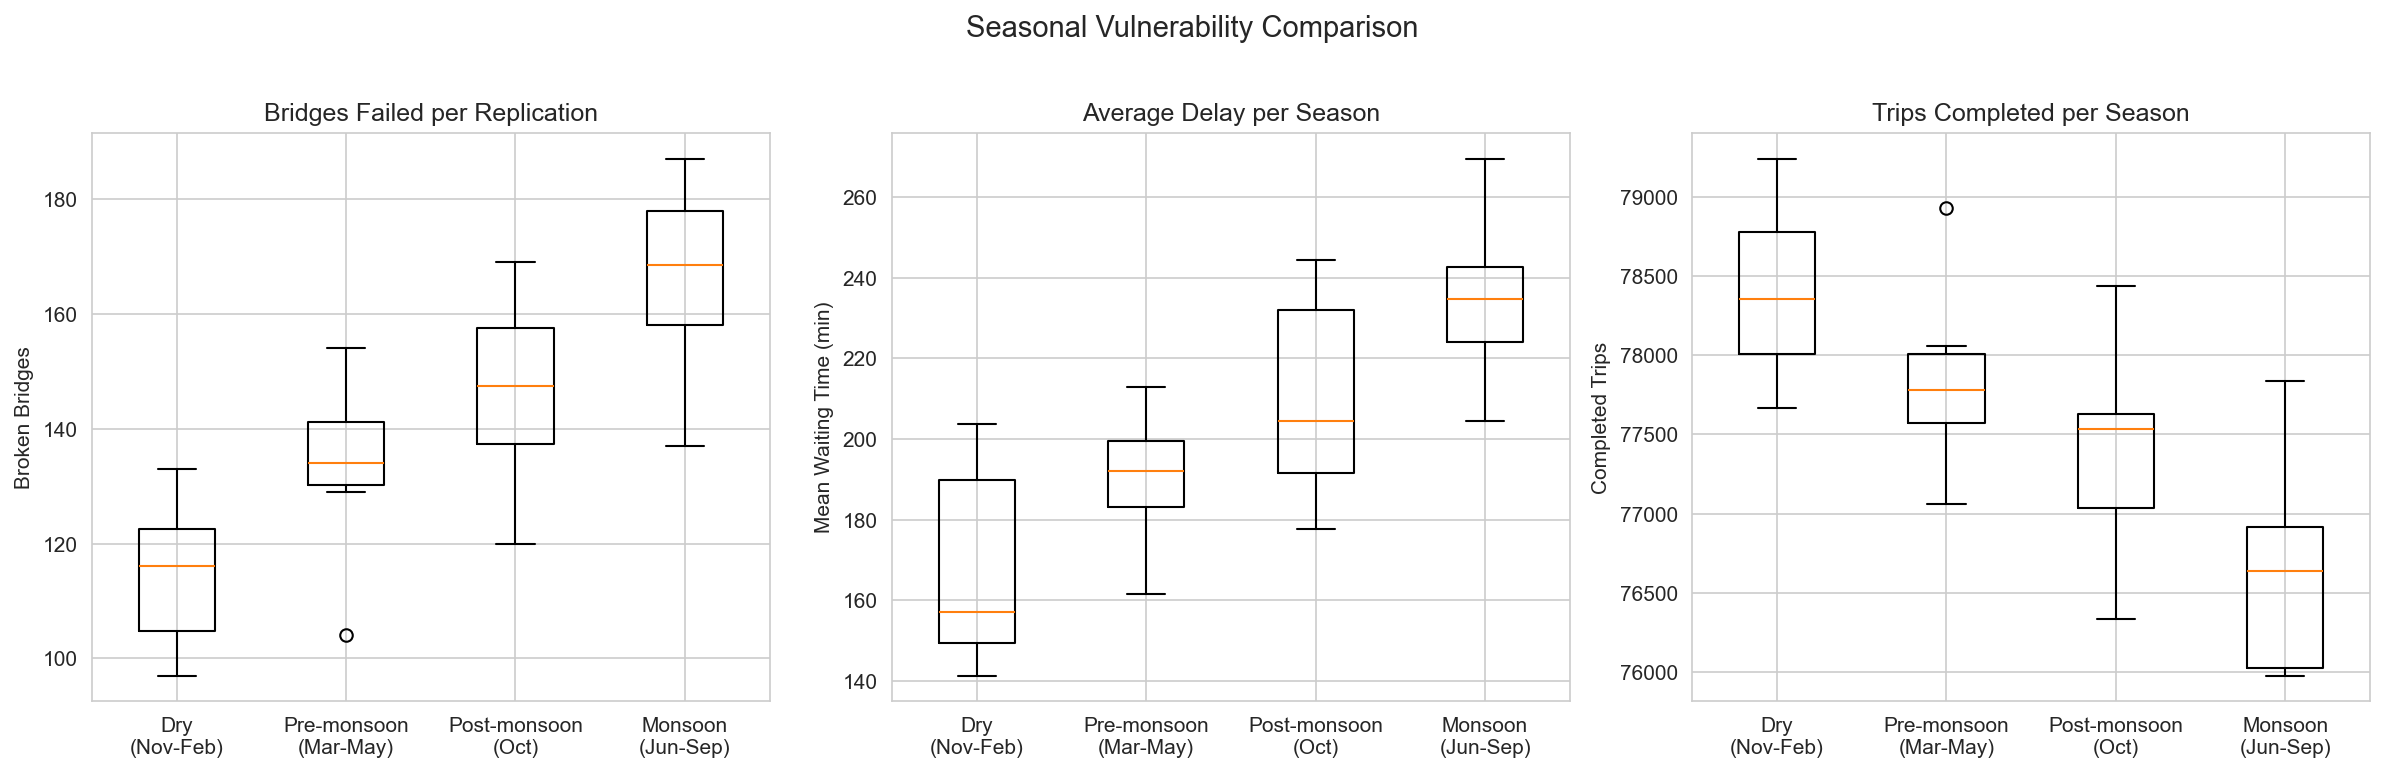

In [54]:
# Figure 3: Seasonal comparison — broken bridges and delays
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

season_labels = {'dry_season': 'Dry\n(Nov-Feb)', 'pre_monsoon': 'Pre-monsoon\n(Mar-May)',
                 'post_monsoon': 'Post-monsoon\n(Oct)', 'monsoon_peak': 'Monsoon\n(Jun-Sep)'}
season_colors = ['#81C784', '#FFD54F', '#FFB74D', '#E57373']

# 3a: Average broken bridges per replication
ax = axes[0]
broken_counts = []
for scenario in scenarios:
    df = pd.read_csv(f'{R2_DIR}/{scenario}_bridges.csv')
    per_rep = df.groupby('replication')['broken_down'].sum()
    broken_counts.append(per_rep.values)
ax.boxplot(broken_counts, labels=[season_labels[s] for s in scenarios])
ax.set_ylabel('Broken Bridges')
ax.set_title('Bridges Failed per Replication')

# 3b: Average waiting time
ax = axes[1]
wait_data = []
for scenario in scenarios:
    df = pd.read_csv(f'{R2_DIR}/{scenario}_trips.csv')
    per_rep = df.groupby('replication')['total_waiting_time'].mean()
    wait_data.append(per_rep.values)
ax.boxplot(wait_data, labels=[season_labels[s] for s in scenarios])
ax.set_ylabel('Mean Waiting Time (min)')
ax.set_title('Average Delay per Season')

# 3c: Total trips completed
ax = axes[2]
trip_counts = []
for scenario in scenarios:
    df = pd.read_csv(f'{R2_DIR}/{scenario}_trips.csv')
    completed = df[df['dest_road'] != 'stranded']
    per_rep = completed.groupby('replication').size()
    trip_counts.append(per_rep.values)
ax.boxplot(trip_counts, labels=[season_labels[s] for s in scenarios])
ax.set_ylabel('Completed Trips')
ax.set_title('Trips Completed per Season')

plt.suptitle('Seasonal Vulnerability Comparison', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f'{IMG_DIR}/seasonal_comparison.png', bbox_inches='tight')
plt.show()

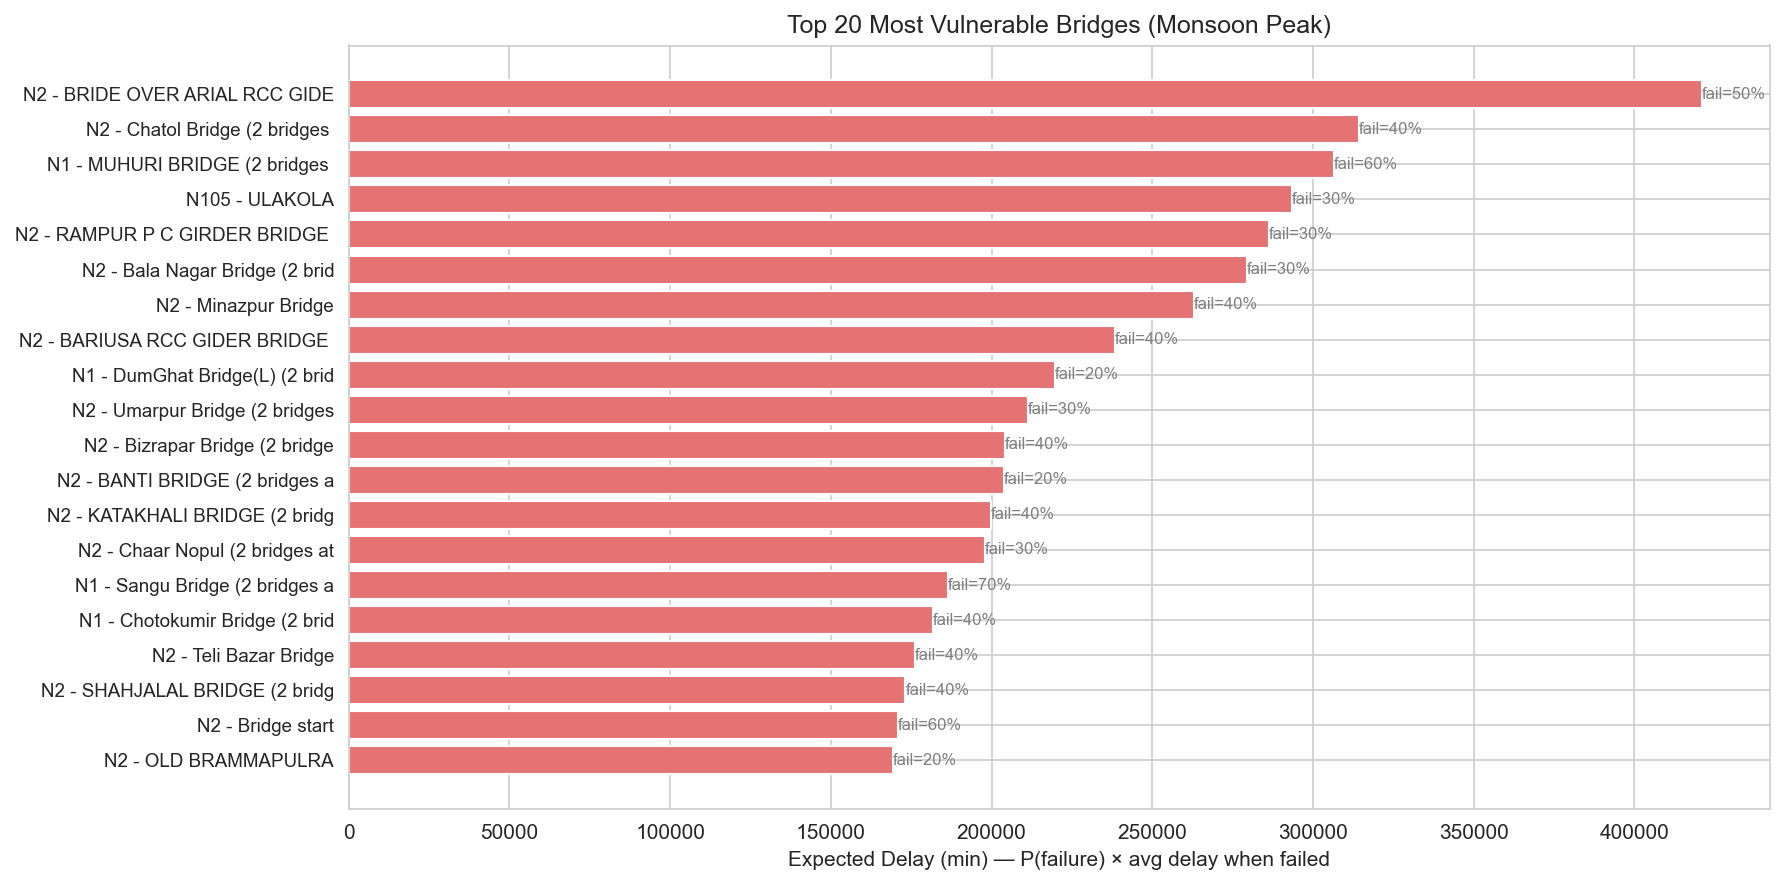

In [55]:
# Figure 4: Top 20 vulnerable bridges (monsoon peak)
fig, ax = plt.subplots(figsize=(12, 6))

top20_vuln = monsoon.head(20).copy()
# Get bridge names from criticality data
top20_vuln = top20_vuln.merge(crit[['bridge_id', 'road', 'name']], on='bridge_id', how='left')
top20_vuln['label'] = top20_vuln.apply(
    lambda r: f"{r['road']} - {str(r['name'])[:25]}" if pd.notna(r['name']) else str(r['road']), axis=1)

ax.barh(range(len(top20_vuln)), top20_vuln['expected_delay'], color='#E57373', edgecolor='white')
ax.set_yticks(range(len(top20_vuln)))
ax.set_yticklabels(top20_vuln['label'], fontsize=9)
ax.set_xlabel('Expected Delay (min) — P(failure) × avg delay when failed')
ax.set_title('Top 20 Most Vulnerable Bridges (Monsoon Peak)')
ax.invert_yaxis()

# Add failure rate annotation
for i, (_, row) in enumerate(top20_vuln.iterrows()):
    ax.text(row['expected_delay'] + 1, i, f"fail={row['failure_rate']:.0%}",
            va='center', fontsize=8, color='gray')

plt.tight_layout()
plt.savefig(f'{IMG_DIR}/top20_vulnerable_bridges.png', bbox_inches='tight')
plt.show()

## 3. Combined — Priority Matrix (Criticality × Vulnerability)

In [56]:
# Build priority matrix: merge criticality + monsoon vulnerability
vuln_monsoon = vuln_all[vuln_all['scenario'] == 'monsoon_peak'][
    ['bridge_id', 'failure_rate', 'expected_delay', 'mean_delay_when_failed', 'mean_vehicles_delayed']
].copy()

priority = crit.merge(vuln_monsoon, on='bridge_id', how='left')
priority['failure_rate'] = priority['failure_rate'].fillna(0)
priority['expected_delay'] = priority['expected_delay'].fillna(0)

# Normalise criticality and vulnerability to [0, 1]
priority['norm_criticality'] = priority['criticality_score']  # already [0, 1]

v_min, v_max = priority['expected_delay'].min(), priority['expected_delay'].max()
priority['norm_vulnerability'] = (priority['expected_delay'] - v_min) / (v_max - v_min) if v_max > v_min else 0

# Priority scores (3 weight configs for sensitivity)
priority['priority_equal'] = 0.5 * priority['norm_criticality'] + 0.5 * priority['norm_vulnerability']
priority['priority_crit_heavy'] = 0.7 * priority['norm_criticality'] + 0.3 * priority['norm_vulnerability']
priority['priority_vuln_heavy'] = 0.3 * priority['norm_criticality'] + 0.7 * priority['norm_vulnerability']

priority = priority.sort_values('priority_equal', ascending=False)
priority['priority_rank'] = range(1, len(priority) + 1)

# Quadrant classification at median thresholds
c_med = priority['norm_criticality'].median()
v_med = priority['norm_vulnerability'].median()

def quadrant(row):
    hi_c = row['norm_criticality'] >= c_med
    hi_v = row['norm_vulnerability'] >= v_med
    if hi_c and hi_v: return 'A'      # Urgent
    if hi_c: return 'B'               # Monitor
    if hi_v: return 'C'               # Maintain
    return 'D'                         # Routine

priority['quadrant'] = priority.apply(quadrant, axis=1)

# Save for reference
priority.to_csv('../experiment/round3_combined/priority_matrix.csv', index=False)
vuln_all.to_csv('../experiment/round3_combined/vulnerability_summary.csv', index=False)

print('Quadrant distribution:')
labels = {'A': 'Urgent', 'B': 'Monitor', 'C': 'Maintain', 'D': 'Routine'}
for q, n in priority['quadrant'].value_counts().sort_index().items():
    print(f'  {q} ({labels[q]}): {n} bridges')

print(f'\nTop 10 overall priority:')
priority.head(10)[['priority_rank', 'bridge_id', 'road', 'name', 'condition',
                    'norm_criticality', 'norm_vulnerability', 'priority_equal', 'quadrant']].round(3)

Quadrant distribution:
  A (Urgent): 271 bridges
  B (Monitor): 98 bridges
  C (Maintain): 98 bridges
  D (Routine): 270 bridges

Top 10 overall priority:


,priority_rank,bridge_id,road,name,condition,norm_criticality,norm_vulnerability,priority_equal,quadrant
14,1,2000303,N2,Chatol Bridge (2 bridges at crossing),A,1.000,0.746,0.873,A
12,2,2000314,N2,RAMPUR P C GIRDER BRIDGE (2 bridges at crossing),C,1.000,0.680,0.840,A
19,3,2000288,N2,BARIUSA RCC GIDER BRIDGE (2 bridges at crossing),C,1.000,0.566,0.783,A
124,4,2000175,N2,BRIDE OVER ARIAL RCC GIDER BRIDGE (2 bridges a...,C,0.478,1.000,0.739,A
11,5,2000316,N2,KATAKHALI BRIDGE (2 bridges at crossing),A,1.000,0.474,0.737,A
10,6,2000320,N2,Khilsima Bridge,C,1.000,0.391,0.695,A
5,7,2000346,N2,KHATABARI CULVERT,A,1.000,0.378,0.689,A
22,8,2000491,N2,Bridge start,B,0.903,0.406,0.654,A
75,9,1000402,N1,MUHURI BRIDGE (2 bridges at crossing),B,0.566,0.728,0.647,A
15,10,2000297,N2,BARURA BOX CULVERT,A,1.000,0.264,0.632,A


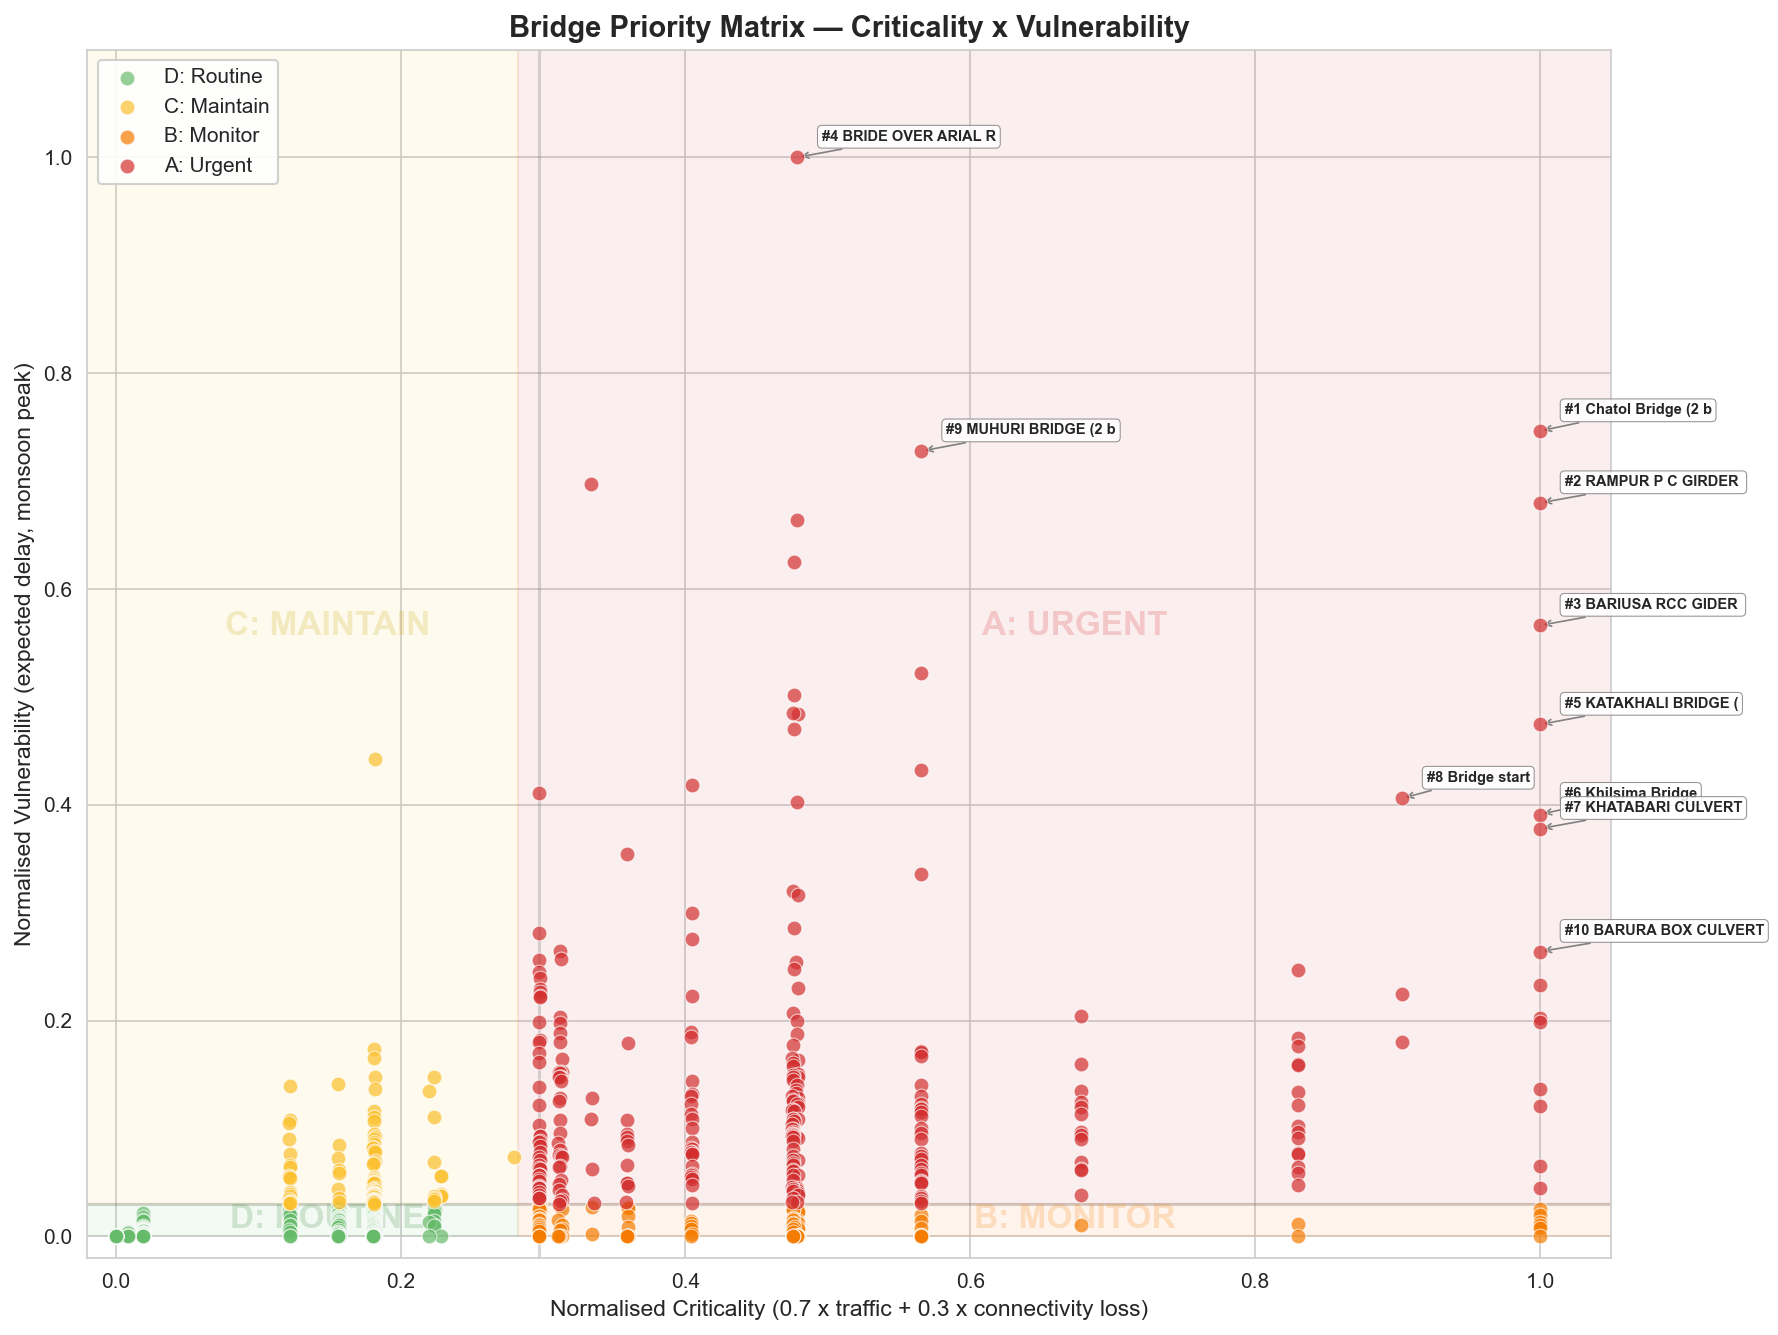

In [57]:
# Figure 5: Criticality x Vulnerability scatter — quadrant labels inside areas
fig, ax = plt.subplots(figsize=(12, 9))

quad_colors = {'A': '#d32f2f', 'B': '#f57c00', 'C': '#fbc02d', 'D': '#66bb6a'}
quad_labels = {'A': 'A: Urgent', 'B': 'B: Monitor', 'C': 'C: Maintain', 'D': 'D: Routine'}

x_max = 1.05
y_max = max(priority['norm_vulnerability'].max() * 1.1, 1.05)

# Quadrant background shading
ax.axhspan(v_med, y_max, xmin=c_med/x_max, xmax=1, color='#d32f2f', alpha=0.08)
ax.axhspan(0, v_med, xmin=c_med/x_max, xmax=1, color='#f57c00', alpha=0.08)
ax.axhspan(v_med, y_max, xmin=0, xmax=c_med/x_max, color='#fbc02d', alpha=0.08)
ax.axhspan(0, v_med, xmin=0, xmax=c_med/x_max, color='#66bb6a', alpha=0.08)

# Quadrant divider lines
ax.axvline(c_med, color='gray', linestyle='-', alpha=0.3, linewidth=1.5)
ax.axhline(v_med, color='gray', linestyle='-', alpha=0.3, linewidth=1.5)

# Quadrant labels — positioned inside the actual data areas
mid_c_hi = (c_med + x_max) / 2
mid_c_lo = c_med / 2
mid_v_hi = (v_med + y_max) / 2
mid_v_lo = v_med / 2

ax.text(mid_c_hi, mid_v_hi, 'A: URGENT', fontsize=16, fontweight='bold',
        color='#d32f2f', alpha=0.2, ha='center', va='center')
ax.text(mid_c_hi, mid_v_lo, 'B: MONITOR', fontsize=16, fontweight='bold',
        color='#f57c00', alpha=0.2, ha='center', va='center')
ax.text(mid_c_lo, mid_v_hi, 'C: MAINTAIN', fontsize=16, fontweight='bold',
        color='#c8a600', alpha=0.2, ha='center', va='center')
ax.text(mid_c_lo, mid_v_lo, 'D: ROUTINE', fontsize=16, fontweight='bold',
        color='#388e3c', alpha=0.2, ha='center', va='center')

# Plot points per quadrant
for q in ['D', 'C', 'B', 'A']:
    mask = priority['quadrant'] == q
    ax.scatter(priority.loc[mask, 'norm_criticality'],
               priority.loc[mask, 'norm_vulnerability'],
               c=quad_colors[q], label=quad_labels[q],
               alpha=0.7, s=50, edgecolors='white', linewidth=0.5,
               zorder=4 if q == 'A' else 3)

# Label top 10
for _, row in priority.head(10).iterrows():
    name_short = str(row['name'])[:18] if pd.notna(row['name']) else ''
    ax.annotate(f"#{int(row['priority_rank'])} {name_short}",
                (row['norm_criticality'], row['norm_vulnerability']),
                fontsize=7, fontweight='bold',
                xytext=(12, 8), textcoords='offset points',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.85, edgecolor='gray', linewidth=0.5),
                arrowprops=dict(arrowstyle='->', color='gray', lw=0.8))

ax.set_xlabel('Normalised Criticality (0.7 x traffic + 0.3 x connectivity loss)', fontsize=11)
ax.set_ylabel('Normalised Vulnerability (expected delay, monsoon peak)', fontsize=11)
ax.set_title('Bridge Priority Matrix — Criticality x Vulnerability', fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=10, framealpha=0.9)
ax.set_xlim(-0.02, x_max)
ax.set_ylim(-0.02, y_max)

plt.tight_layout()
plt.savefig(f'{IMG_DIR}/priority_scatter.png', bbox_inches='tight')
plt.show()


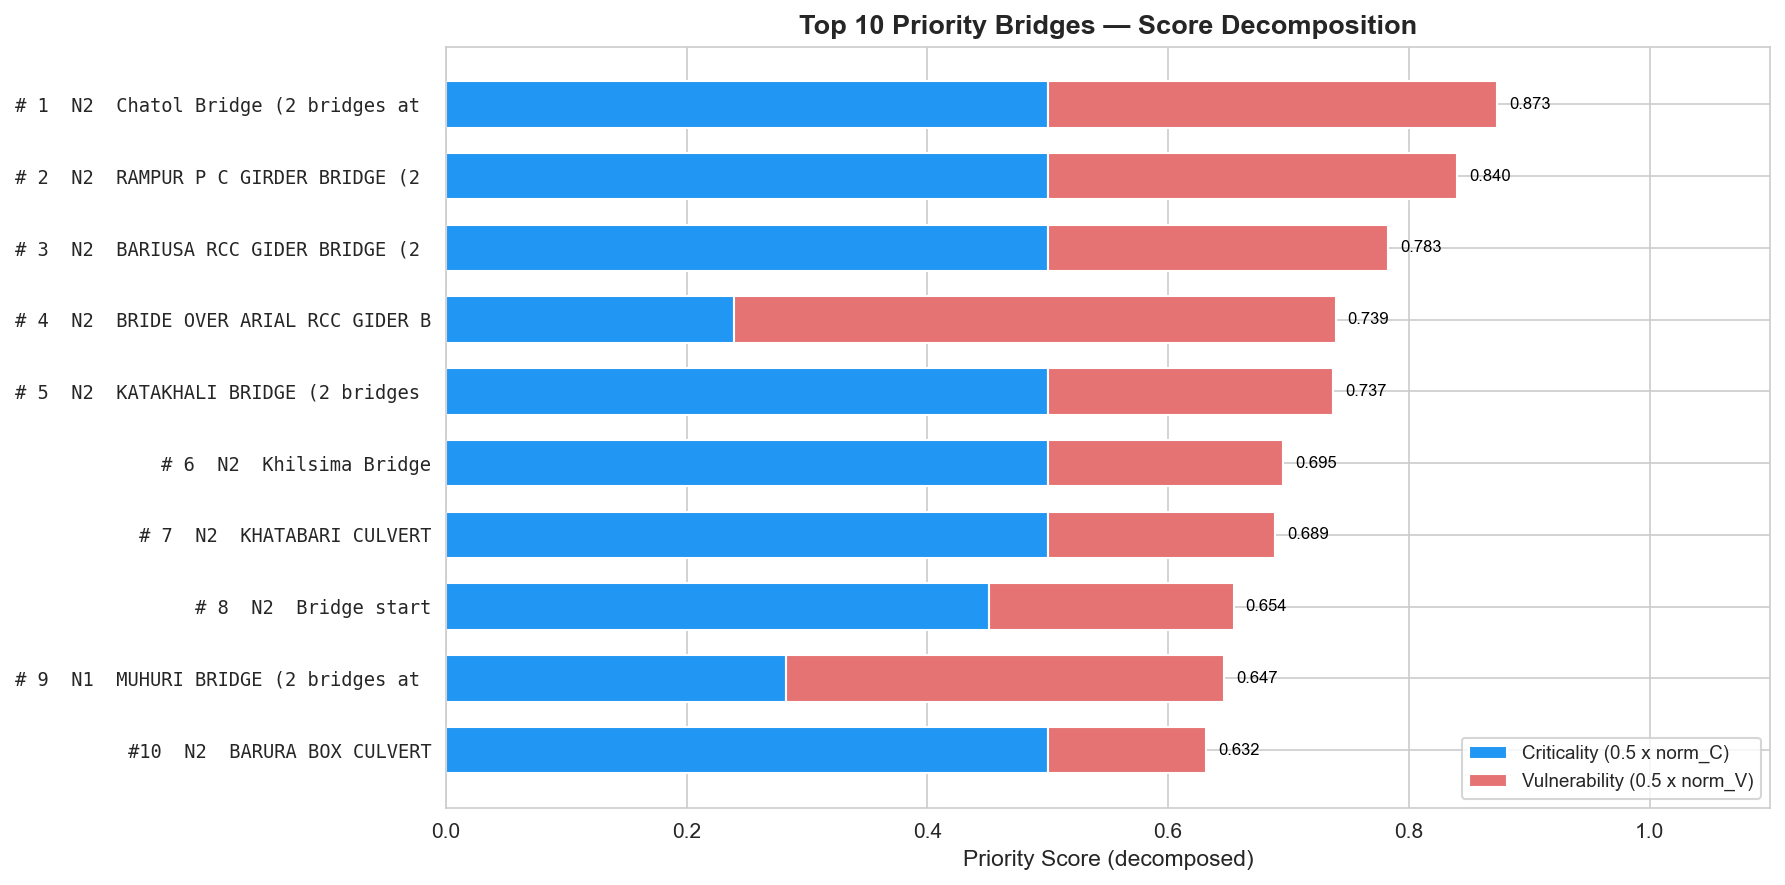

In [58]:
# Figure 6a: Top 10 priority — decomposed score bars
fig, ax = plt.subplots(figsize=(12, 6))

top10_p = priority.head(10).copy()
top10_p['c_contrib'] = 0.5 * top10_p['norm_criticality']
top10_p['v_contrib'] = 0.5 * top10_p['norm_vulnerability']
top10_p['label'] = top10_p.apply(
    lambda r: f"#{int(r['priority_rank']):2d}  {r['road']}  {str(r['name'])[:28]}" if pd.notna(r['name']) else f"#{int(r['priority_rank']):2d}  {r['road']}", axis=1)
top10_p = top10_p.iloc[::-1]

y = np.arange(len(top10_p))
ax.barh(y, top10_p['c_contrib'].values, color='#2196F3',
        label='Criticality (0.5 x norm_C)', height=0.65)
ax.barh(y, top10_p['v_contrib'].values, left=top10_p['c_contrib'].values,
        color='#E57373', label='Vulnerability (0.5 x norm_V)', height=0.65)

ax.set_yticks(y)
ax.set_yticklabels(top10_p['label'], fontsize=9, fontfamily='monospace')
ax.set_xlabel('Priority Score (decomposed)', fontsize=11)
ax.set_title('Top 10 Priority Bridges — Score Decomposition', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.set_xlim(0, 1.1)

for i, (_, row) in enumerate(top10_p.iterrows()):
    ax.text(row['priority_equal'] + 0.01, i, f"{row['priority_equal']:.3f}",
            va='center', fontsize=8, color='black')

plt.tight_layout()
plt.savefig(f'{IMG_DIR}/priority_decomposed.png', bbox_inches='tight')
plt.show()


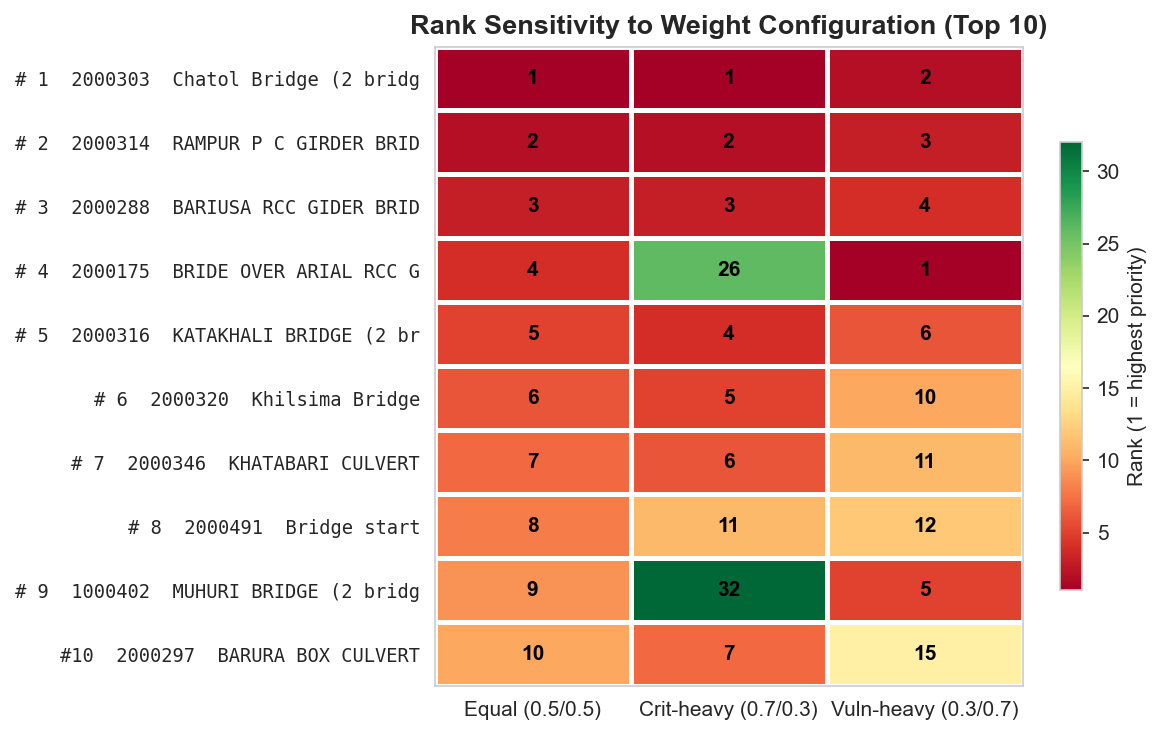

In [59]:
# Figure 6b: Sensitivity heatmap — top 10 rank stability
configs = {
    'Equal (0.5/0.5)': 'priority_equal',
    'Crit-heavy (0.7/0.3)': 'priority_crit_heavy',
    'Vuln-heavy (0.3/0.7)': 'priority_vuln_heavy',
}
top10_ids = priority.head(10)['bridge_id'].tolist()

rank_matrix = pd.DataFrame(index=top10_ids, columns=list(configs.keys()))
for col_label, score_col in configs.items():
    ranked = priority.sort_values(score_col, ascending=False).reset_index(drop=True)
    ranked['_rank'] = ranked.index + 1
    lookup = ranked.set_index('bridge_id')['_rank']
    for bid in top10_ids:
        rank_matrix.loc[bid, col_label] = int(lookup[bid])
rank_matrix = rank_matrix.astype(int)

row_labels = [
    f"#{priority[priority['bridge_id']==bid]['priority_rank'].values[0]:2d}  "
    f"{bid}  {str(priority[priority['bridge_id']==bid]['name'].values[0])[:22]}"
    for bid in top10_ids
]

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.pcolormesh(np.arange(len(configs)+1), np.arange(len(top10_ids)+1),
                    rank_matrix.values, cmap='RdYlGn',
                    vmin=1, vmax=max(20, rank_matrix.values.max()),
                    edgecolors='white', linewidth=1.5)

ax.set_xticks(np.arange(len(configs)) + 0.5)
ax.set_xticklabels(list(configs.keys()), fontsize=10)
ax.set_yticks(np.arange(len(row_labels)) + 0.5)
ax.set_yticklabels(row_labels, fontsize=9, fontfamily='monospace')
ax.set_title('Rank Sensitivity to Weight Configuration (Top 10)', fontsize=13, fontweight='bold')
ax.invert_yaxis()

for i in range(len(top10_ids)):
    for j in range(len(configs)):
        val = rank_matrix.iloc[i, j]
        ax.text(j + 0.5, i + 0.5, str(val), ha='center', va='center',
                fontsize=10, fontweight='bold', color='black')

plt.colorbar(im, ax=ax, label='Rank (1 = highest priority)', shrink=0.7)
plt.tight_layout()
plt.savefig(f'{IMG_DIR}/sensitivity_heatmap.png', bbox_inches='tight')
plt.show()


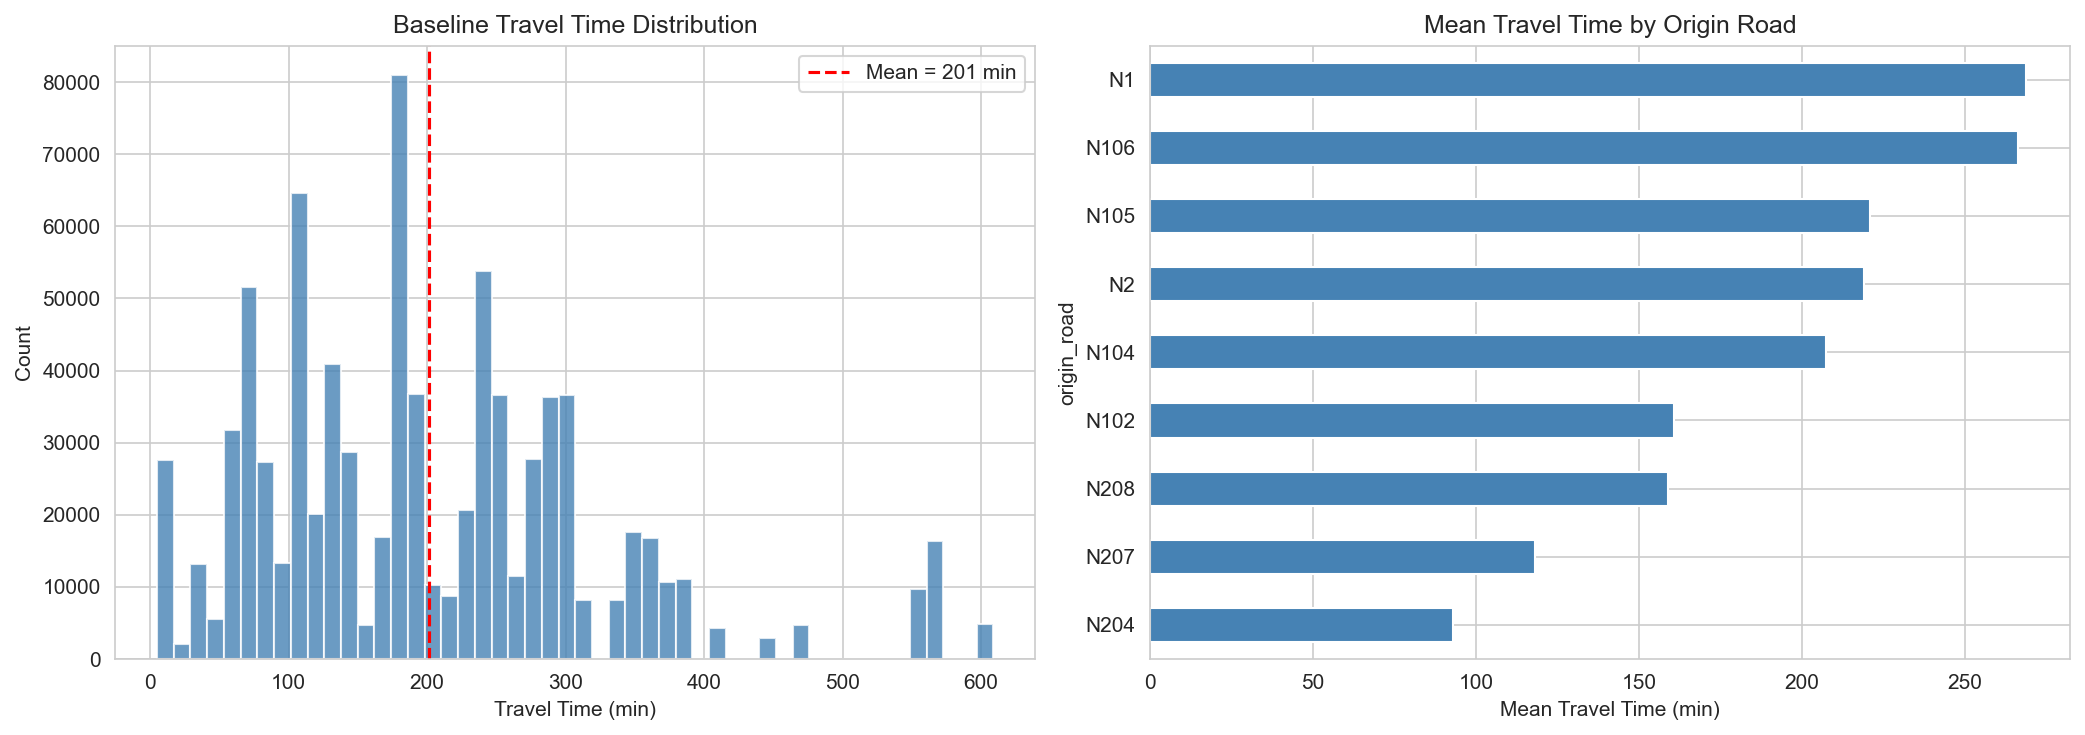

In [60]:
# Figure 7: Baseline travel time distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

baseline_trips = pd.read_csv(f'{R1_DIR}/trips.csv')
baseline_completed = baseline_trips[baseline_trips['dest_road'] != 'stranded']

# 7a: Travel time distribution
ax = axes[0]
ax.hist(baseline_completed['travel_time'], bins=50, color='steelblue',
        edgecolor='white', alpha=0.8)
ax.axvline(baseline_completed['travel_time'].mean(), color='red',
           linestyle='--', label=f"Mean = {baseline_completed['travel_time'].mean():.0f} min")
ax.set_xlabel('Travel Time (min)')
ax.set_ylabel('Count')
ax.set_title('Baseline Travel Time Distribution')
ax.legend()

# 7b: Travel time by origin road
ax = axes[1]
road_times = baseline_completed.groupby('origin_road')['travel_time'].mean().sort_values()
road_times.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_xlabel('Mean Travel Time (min)')
ax.set_title('Mean Travel Time by Origin Road')

plt.tight_layout()
plt.savefig(f'{IMG_DIR}/baseline_travel_time.png', bbox_inches='tight')
plt.show()

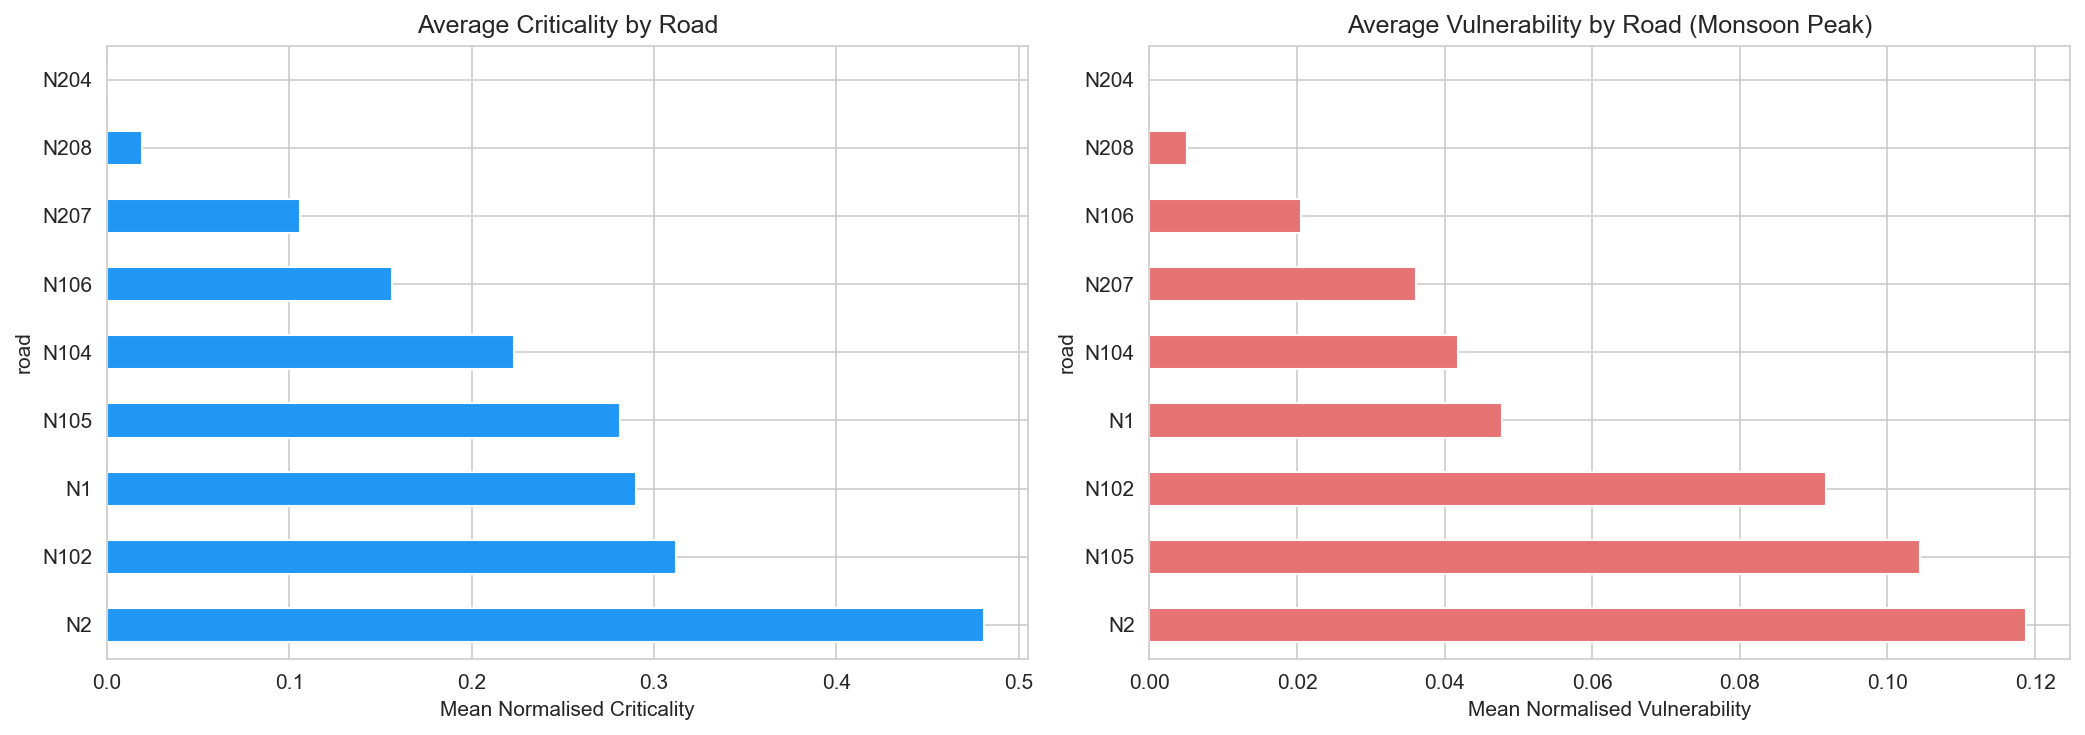

Per-road summary:


,mean_criticality,mean_vulnerability,n_bridges,n_quadrant_a
road,,,,
N2,0.481,0.119,243,176
N102,0.312,0.092,42,32
N1,0.290,0.048,279,59
N105,0.281,0.104,12,4
N104,0.223,0.042,15,0
N106,0.156,0.021,49,0
N207,0.106,0.036,35,0
N208,0.019,0.005,44,0
N204,0.000,0.000,18,0


In [61]:
# Figure 8: Per-road criticality and vulnerability comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

road_crit = priority.groupby('road').agg(
    mean_criticality=('norm_criticality', 'mean'),
    mean_vulnerability=('norm_vulnerability', 'mean'),
    n_bridges=('bridge_id', 'count'),
    n_quadrant_a=('quadrant', lambda x: (x == 'A').sum()),
).sort_values('mean_criticality', ascending=False)

# 8a: Mean criticality per road
ax = axes[0]
road_crit['mean_criticality'].plot(kind='barh', ax=ax, color='#2196F3', edgecolor='white')
ax.set_xlabel('Mean Normalised Criticality')
ax.set_title('Average Criticality by Road')

# 8b: Mean vulnerability per road
ax = axes[1]
road_crit.sort_values('mean_vulnerability', ascending=False)['mean_vulnerability'].plot(
    kind='barh', ax=ax, color='#E57373', edgecolor='white')
ax.set_xlabel('Mean Normalised Vulnerability')
ax.set_title('Average Vulnerability by Road (Monsoon Peak)')

plt.tight_layout()
plt.savefig(f'{IMG_DIR}/road_comparison.png', bbox_inches='tight')
plt.show()

print('Per-road summary:')
road_crit.round(3)

## Top 10 Priority Bridges — Location Map

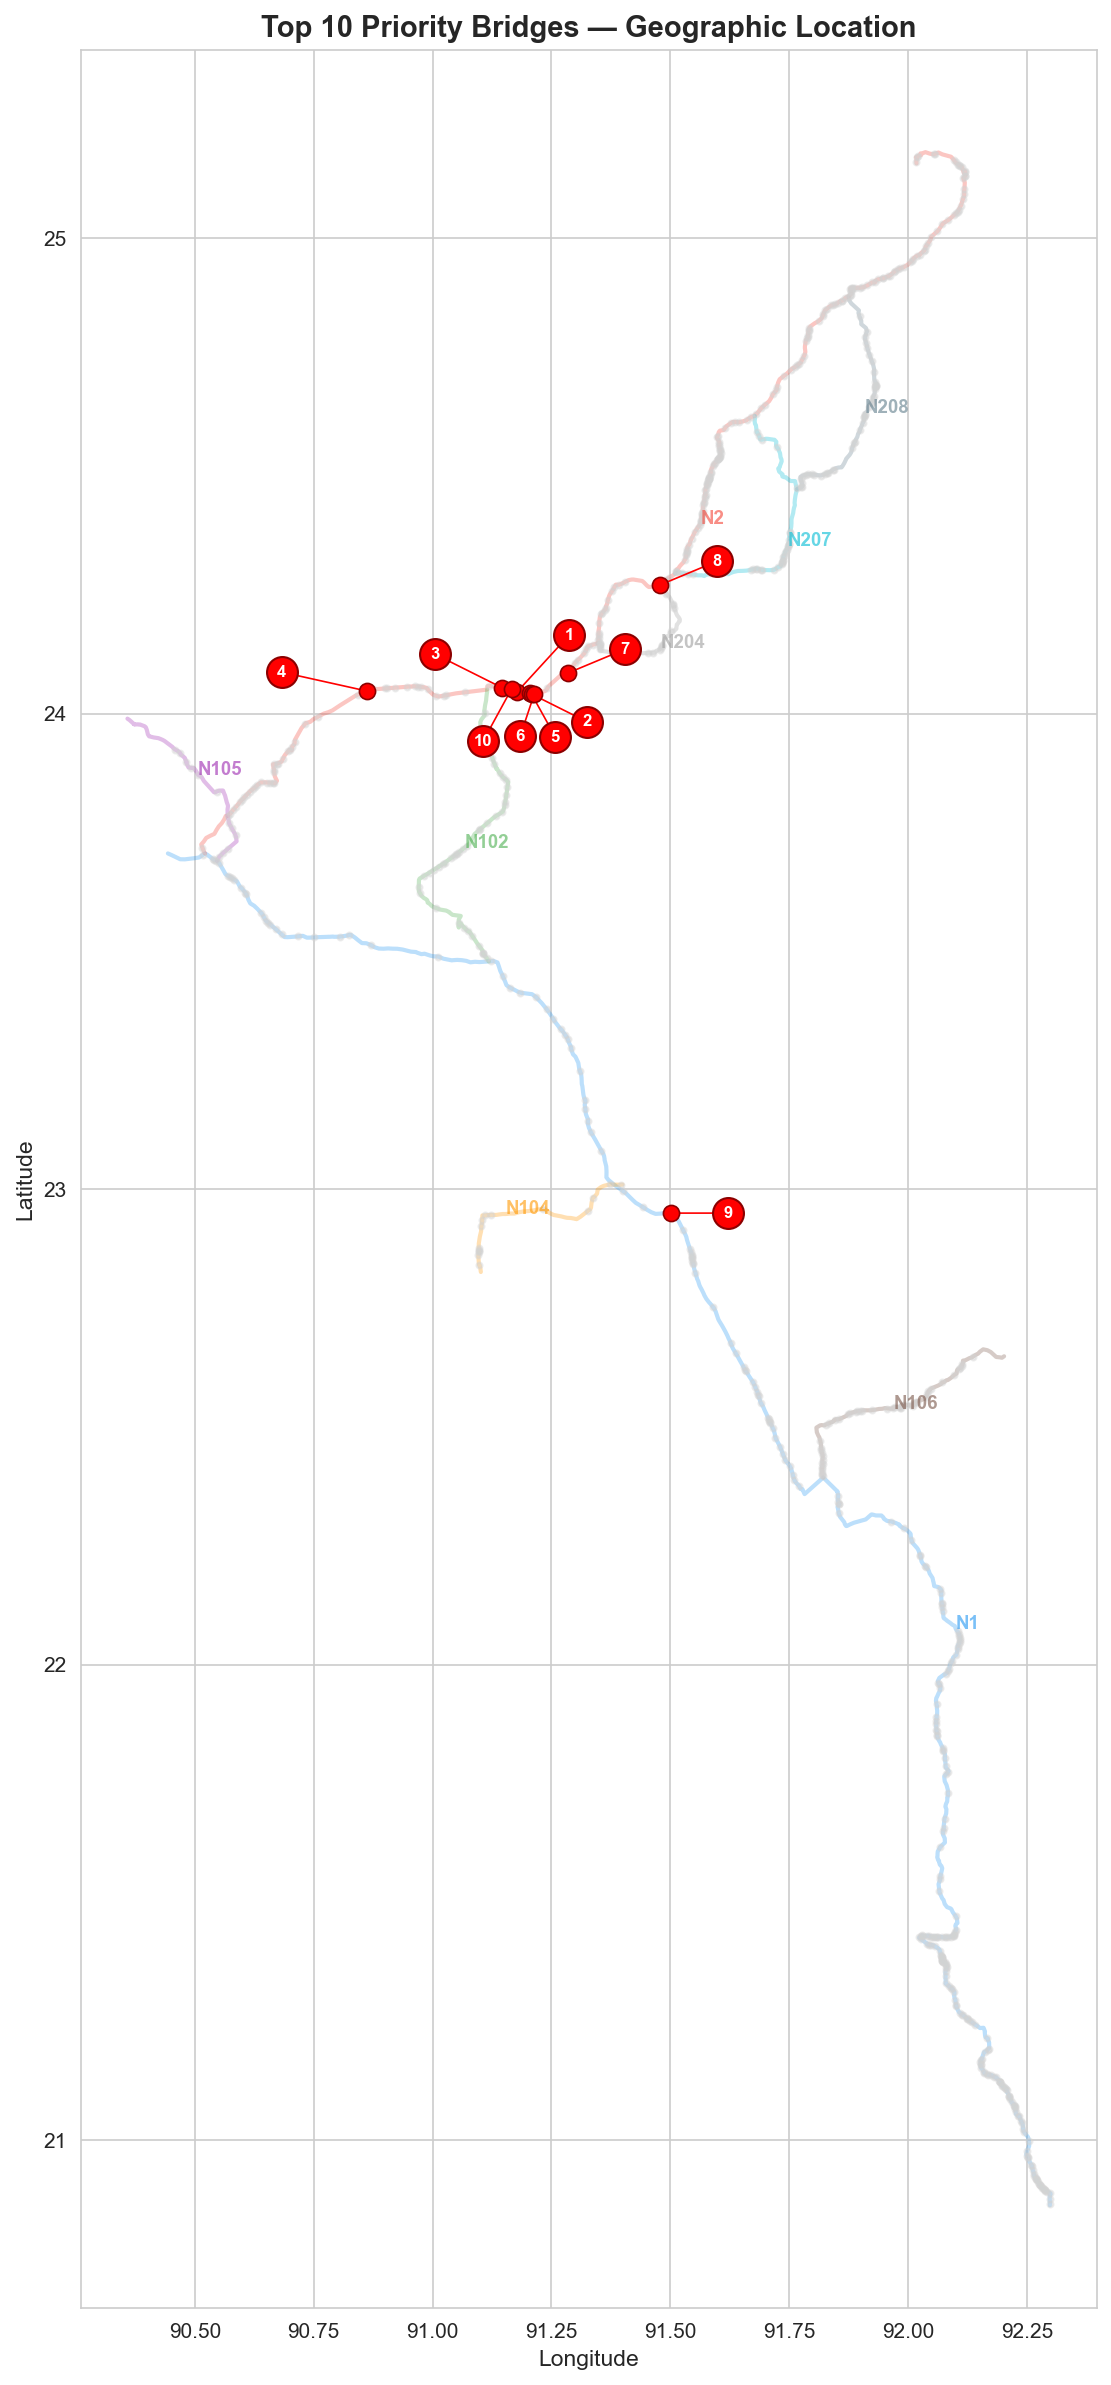

In [62]:
# Figure 9: Top 10 priority bridges — geographic location
net = pd.read_csv('../data/integrated_data.csv')
top10 = priority.head(10).copy()

fig, ax = plt.subplots(figsize=(10, 16))

road_colors = {
    'N1': '#2196F3', 'N2': '#F44336', 'N102': '#4CAF50', 'N104': '#FF9800',
    'N105': '#9C27B0', 'N106': '#795548', 'N204': '#9E9E9E', 'N207': '#00BCD4', 'N208': '#607D8B'
}

# Road lines
for road in net['road'].unique():
    rd = net[net['road'] == road]
    ax.plot(rd['lon'], rd['lat'], '-', color=road_colors.get(road, 'gray'),
            alpha=0.3, linewidth=2)

# All bridges (background)
ax.scatter(priority['lon'], priority['lat'], s=8, c='lightgray', alpha=0.4, zorder=2)

# Per-rank label offsets — spread the dense cluster
label_offsets = {
    1:  ( 0.11,  0.12),
    2:  ( 0.12, -0.06),
    3:  (-0.14,  0.07),
    4:  (-0.18,  0.04),
    5:  (0.05, -0.09),
    6:  ( -0.03, -0.09),
    7:  ( 0.12,  0.05),
    8:  ( 0.12,  0.05),
    9:  ( 0.12,  0.00),
    10: ( -0.06, -0.11),
}

for _, row in top10.iterrows():
    rank = int(row['priority_rank'])
    lon, lat = row['lon'], row['lat']
    dx, dy = label_offsets.get(rank, (0.10, 0.06))
    llon, llat = lon + dx, lat + dy

    # True-location dot
    ax.scatter(lon, lat, s=60, c='red', edgecolors='darkred',
               linewidth=0.8, zorder=5)

    # Leader line
    ax.annotate(
        '', xy=(lon, lat), xytext=(llon, llat),
        arrowprops=dict(arrowstyle='-', color='red',
                        lw=0.8, connectionstyle='arc3,rad=0.0'),
        zorder=4
    )

    # Numbered circle at offset position
    ax.scatter(llon, llat, s=220, c='red', edgecolors='darkred',
               linewidth=1.0, zorder=6)
    ax.text(llon, llat, str(rank), fontsize=8, fontweight='bold',
            color='white', ha='center', va='center', zorder=7)

# Road labels
for road in net['road'].unique():
    rd = net[net['road'] == road]
    mid = rd.iloc[len(rd) // 2]
    ax.text(mid['lon'], mid['lat'], road, fontsize=9, fontweight='bold',
            color=road_colors.get(road, 'gray'), alpha=0.6)

ax.set_xlabel('Longitude', fontsize=11)
ax.set_ylabel('Latitude', fontsize=11)
ax.set_title('Top 10 Priority Bridges — Geographic Location', fontsize=14, fontweight='bold')
ax.set_aspect('equal')
plt.tight_layout()
plt.savefig(f'{IMG_DIR}/top10_priority_map.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. Summary Tables for Report

In [63]:
# Final top 10 priority table for the report
report_cols = ['priority_rank', 'bridge_id', 'road', 'name', 'condition',
               'avg_trucks_crossed', 'broken_pct', 'failure_rate',
               'expected_delay', 'norm_criticality', 'norm_vulnerability',
               'priority_equal', 'quadrant']

print('=== TOP 10 PRIORITY BRIDGES (for report) ===')
priority.head(10)[report_cols].round(3)

=== TOP 10 PRIORITY BRIDGES (for report) ===


,priority_rank,bridge_id,road,name,condition,avg_trucks_crossed,broken_pct,failure_rate,expected_delay,norm_criticality,norm_vulnerability,priority_equal,quadrant
14,1,2000303,N2,Chatol Bridge (2 bridges at crossing),A,30342.5,50.33,0.4,314350.5,1.000,0.746,0.873,A
12,2,2000314,N2,RAMPUR P C GIRDER BRIDGE (2 bridges at crossing),C,30342.9,50.33,0.3,286251.1,1.000,0.680,0.840,A
19,3,2000288,N2,BARIUSA RCC GIDER BRIDGE (2 bridges at crossing),C,30339.3,50.33,0.4,238437.4,1.000,0.566,0.783,A
124,4,2000175,N2,BRIDE OVER ARIAL RCC GIDER BRIDGE (2 bridges a...,C,20737.3,0.00,0.5,421127.2,0.478,1.000,0.739,A
11,5,2000316,N2,KATAKHALI BRIDGE (2 bridges at crossing),A,30344.5,50.33,0.4,199804.6,1.000,0.474,0.737,A
10,6,2000320,N2,Khilsima Bridge,C,30344.6,50.33,0.3,164647.8,1.000,0.391,0.695,A
5,7,2000346,N2,KHATABARI CULVERT,A,30348.8,50.33,0.3,159138.2,1.000,0.378,0.689,A
22,8,2000491,N2,Bridge start,B,28173.0,42.48,0.6,170944.3,0.903,0.406,0.654,A
75,9,1000402,N1,MUHURI BRIDGE (2 bridges at crossing),B,16921.4,29.41,0.6,306510.5,0.566,0.728,0.647,A
15,10,2000297,N2,BARURA BOX CULVERT,A,30341.3,50.33,0.2,111158.5,1.000,0.264,0.632,A


In [64]:
# Summary statistics for report
print('=== KEY STATISTICS ===')
print(f'Total bridges analysed: {len(priority)}')
print(f'Bridges that disconnect network: {(priority["broken_pct"] > 0).sum()}')
print(f'Baseline mean travel time: {baseline_completed["travel_time"].mean():.1f} min')
print(f'\nSeasonal impact (monsoon peak vs baseline):')
monsoon_trips = pd.read_csv(f'{R2_DIR}/monsoon_peak_trips.csv')
monsoon_completed = monsoon_trips[monsoon_trips['dest_road'] != 'stranded']
print(f'  Baseline trips/rep: {len(baseline_completed)/10:.0f}')
print(f'  Monsoon trips/rep:  {len(monsoon_completed)/10:.0f}')
print(f'  Baseline mean wait: {baseline_completed["total_waiting_time"].mean():.1f} min')
print(f'  Monsoon mean wait:  {monsoon_completed["total_waiting_time"].mean():.1f} min')
print(f'\nQuadrant distribution:')
for q, n in priority['quadrant'].value_counts().sort_index().items():
    print(f'  {q} ({labels[q]}): {n} bridges ({n/len(priority)*100:.1f}%)')

=== KEY STATISTICS ===
Total bridges analysed: 737
Bridges that disconnect network: 409
Baseline mean travel time: 201.3 min

Seasonal impact (monsoon peak vs baseline):
  Baseline trips/rep: 82416
  Monsoon trips/rep:  76639
  Baseline mean wait: 0.0 min
  Monsoon mean wait:  234.9 min

Quadrant distribution:
  A (Urgent): 271 bridges (36.8%)
  B (Monitor): 98 bridges (13.3%)
  C (Maintain): 98 bridges (13.3%)
  D (Routine): 270 bridges (36.6%)
